# QSVT Hamiltonian simulation validation

この notebook は、新しい QSVT 実装について次を小規模な厳密計算で確認します。

- Jacobi--Anger の cos/sin 位相列が同じ scale を使っていること
- 振幅増幅前の zero-ancilla block が $s e^{-iHt}/2$ であること
- 3-step robust OAA 後の block が $e^{-iHt}$ に近く、成功確率がほぼ 1 になること
- 負の時刻、$t=0$、2量子ビット TFIM のランダム初期状態でも整合すること

密行列は検証だけに使い、回路 builder 自体は密行列を構築しません。

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from qiskit.quantum_info import Operator
from scipy.linalg import expm

from hamiltonian_resources import (
    PauliHamiltonian,
    build_hamiltonian_qsvt_circuit,
    compare_with_exact,
    synthesize_hamsim_phases,
    transverse_field_ising,
)

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=6, suppress=True)

In [2]:
def zero_ancilla_block(circuit, system_qubits):
    """Extract <0...0|U|0...0> using Qiskit's little-endian ordering."""
    unitary = Operator(circuit).data
    ancillas = circuit.num_qubits - system_qubits
    selected = np.arange(2**system_qubits) * 2**ancillas
    return unitary[np.ix_(selected, selected)]


def success_range(block):
    probabilities = np.linalg.eigvalsh(block.conj().T @ block)
    return float(probabilities.min()), float(probabilities.max())

## 1. 位相合成の診断

$H=0.3Z+0.7X$ は非可換な Pauli 項を含み、LCU normalization は $\alpha=1$ です。

In [3]:
H = PauliHamiltonian.from_terms(1, [("Z", 0.3), ("X", 0.7)], name="0.3Z+0.7X")
time = 0.7
epsilon = 1e-3
phases = synthesize_hamsim_phases(H.alpha * time, epsilon)

phase_diagnostics = pd.DataFrame(
    [
        {
            "component": "cos",
            "degree": phases.cosine_degree,
            "common_scale": phases.scale,
            "tail_bound": phases.cosine_tail_bound,
            "phase_residual": phases.cosine_phase_residual,
        },
        {
            "component": "sin",
            "degree": phases.sine_degree,
            "common_scale": phases.scale,
            "tail_bound": phases.sine_tail_bound,
            "phase_residual": phases.sine_phase_residual,
        },
    ]
)
display(phase_diagnostics)

,component,degree,common_scale,tail_bound,phase_residual
0,cos,4,0.999944,6.808013e-06,6.661338e-16
1,sin,5,0.999944,3.404006e-07,5.551115e-16


## 2. 増幅前後の zero block

増幅前は $s e^{-iHt}/2$、増幅後は $e^{-iHt}$ と比較します。成功確率の範囲は、入力状態に対する $B^\dagger B$ の最小・最大固有値です。

In [4]:
unamplified = build_hamiltonian_qsvt_circuit(
    H, time, epsilon, amplitude_amplification=False
)
amplified = build_hamiltonian_qsvt_circuit(H, time, epsilon)
exact = expm(-1j * time * H.matrix())
block_before = zero_ancilla_block(unamplified, H.num_qubits)
block_after = zero_ancilla_block(amplified, H.num_qubits)

before_success = success_range(block_before)
after_success = success_range(block_after)
block_summary = pd.DataFrame(
    [
        {
            "circuit": "before OAA",
            "operator_error": np.linalg.norm(
                block_before - phases.scale * exact / 2, ord=2
            ),
            "success_min": before_success[0],
            "success_max": before_success[1],
            "qubits": unamplified.num_qubits,
        },
        {
            "circuit": "after OAA",
            "operator_error": np.linalg.norm(block_after - exact, ord=2),
            "success_min": after_success[0],
            "success_max": after_success[1],
            "qubits": amplified.num_qubits,
        },
    ]
)
display(block_summary)
print("OAA metadata:", amplified.metadata["oaa_sequence"])

,circuit,operator_error,success_min,success_max,qubits
0,before OAA,0.000001,0.249971,0.249971,4
1,after OAA,0.000001,1.000000,1.000000,4


OAA metadata: -U R U^dagger R U


## 3. 時刻を変えたときの誤差と成功確率

,time,degree,error_before,error_after,success_before,success_after
0,0.1,3,2.468929e-07,1.198840e-07,0.249861,1.0
1,0.3,3,1.991959e-05,7.882999e-06,0.249881,1.0
2,0.7,5,1.167529e-06,1.239786e-06,0.249860,1.0
3,1.0,5,9.785324e-06,1.397529e-05,0.249854,1.0


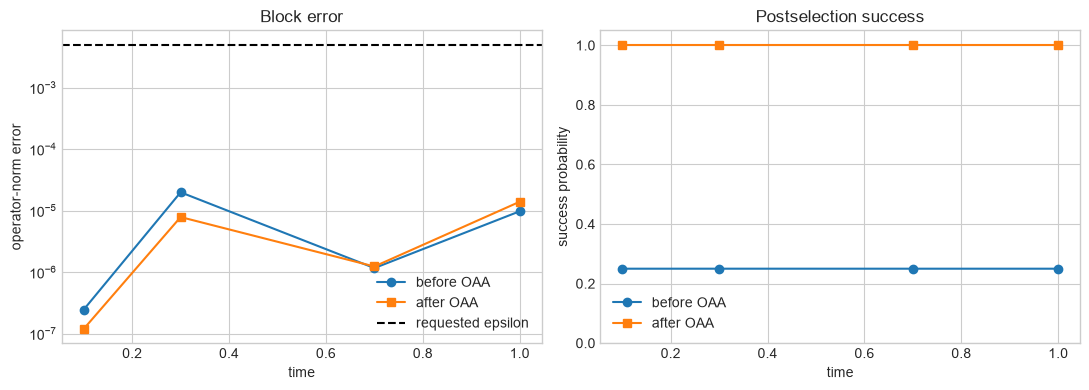

In [5]:
records = []
scan_epsilon = 5e-3
for scan_time in [0.1, 0.3, 0.7, 1.0]:
    before = build_hamiltonian_qsvt_circuit(
        H, scan_time, scan_epsilon, amplitude_amplification=False
    )
    after = build_hamiltonian_qsvt_circuit(H, scan_time, scan_epsilon)
    exact_scan = expm(-1j * scan_time * H.matrix())
    before_block = zero_ancilla_block(before, H.num_qubits)
    after_block = zero_ancilla_block(after, H.num_qubits)
    scale = before.metadata["polynomial_scale"]
    records.append(
        {
            "time": scan_time,
            "degree": max(
                before.metadata["cosine_degree"], before.metadata["sine_degree"]
            ),
            "error_before": np.linalg.norm(
                before_block - scale * exact_scan / 2, ord=2
            ),
            "error_after": np.linalg.norm(after_block - exact_scan, ord=2),
            "success_before": np.mean(success_range(before_block)),
            "success_after": np.mean(success_range(after_block)),
        }
    )

scan = pd.DataFrame(records)
display(scan)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].semilogy(scan["time"], scan["error_before"], "o-", label="before OAA")
axes[0].semilogy(scan["time"], scan["error_after"], "s-", label="after OAA")
axes[0].axhline(scan_epsilon, color="black", linestyle="--", label="requested epsilon")
axes[0].set(xlabel="time", ylabel="operator-norm error", title="Block error")
axes[0].legend()
axes[1].plot(scan["time"], scan["success_before"], "o-", label="before OAA")
axes[1].plot(scan["time"], scan["success_after"], "s-", label="after OAA")
axes[1].set(xlabel="time", ylabel="success probability", ylim=(0, 1.05), title="Postselection success")
axes[1].legend()
plt.tight_layout()

## 4. 2量子ビット TFIM とランダム初期状態

In [6]:
rng = np.random.default_rng(2026)
psi = rng.normal(size=4) + 1j * rng.normal(size=4)
psi /= np.linalg.norm(psi)
H2 = transverse_field_ising(2, coupling=1.0, field=0.7)

state_results = []
for use_oaa in [False, True]:
    result = compare_with_exact(
        H2,
        0.08,
        method="qsvt",
        initial_state=psi,
        qsvt_epsilon=2e-2,
        amplitude_amplification=use_oaa,
    )
    state_results.append({"OAA": use_oaa, **result})
display(pd.DataFrame(state_results))

,OAA,method,state_error,fidelity,success_probability
0,False,qsvt,2.810647e-06,1.0,0.249446
1,True,qsvt,4.621834e-07,1.0,0.999996


## 5. 負の時刻とゼロ時刻

In [7]:
forward = build_hamiltonian_qsvt_circuit(H, 0.2, 1e-2)
backward = build_hamiltonian_qsvt_circuit(H, -0.2, 1e-2)
zero_time = build_hamiltonian_qsvt_circuit(H, 0.0, 1e-2)
forward_block = zero_ancilla_block(forward, H.num_qubits)
backward_block = zero_ancilla_block(backward, H.num_qubits)

edge_cases = pd.DataFrame(
    [
        {
            "check": "U(-t) = U(t)^dagger",
            "error": np.linalg.norm(backward_block - forward_block.conj().T, ord=2),
        },
        {
            "check": "U(0) = I",
            "error": np.linalg.norm(Operator(zero_time).data - np.eye(2), ord=2),
        },
    ]
)
display(edge_cases)

,check,error
0,U(-t) = U(t)^dagger,5.032373e-15
1,U(0) = I,0.000000e+00


## 読み方

正常なら、増幅前の成功確率はおよそ $1/4$、増幅後はほぼ $1$ になります。operator error と state error は指定した `epsilon` より十分小さい範囲に入り、負時刻の回路は正時刻の随伴と一致します。

この notebook は回路の正しさを見るためのものです。解析的リソースモデル（`estimate_resources_analytically`）は quadrature 抽出（`V`/`V^dagger` の query 共有）と 3-step OAA の定数を反映済みで、`resource_comparison.ipynb` の比較は決定的動作あたりで行われます。